# PREPROCESSING

In [ ]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import re

# Download required NLTK data (run once)
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

df = pd.read_csv("blooms_taxonomy_dataset.csv")

# Initialize lemmatizer and stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    if pd.isna(text):
        return ""

    # Convert to lowercase (already done, but ensuring)
    text = str(text).lower()

    # Remove special characters and digits, keep only alphabets
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stopwords and lemmatize
    cleaned_tokens = []
    for token in tokens:
        if token not in stop_words and len(token) > 2:  # Ignore short words
            lemma = lemmatizer.lemmatize(token)
            cleaned_tokens.append(lemma)

    return ' '.join(cleaned_tokens)

# Apply preprocessing to Questions column
df['cleaned_questions'] = df['Questions'].apply(preprocess_text)

# Display results
print("Original vs Cleaned Questions:")
print(df[['Questions', 'cleaned_questions']].head())

# View the first few cleaned questions
print("\nCleaned questions:")
print(df['cleaned_questions'].head())


#Save cleaned dataset
df.to_csv("cleaned_blooms_taxonomy_dataset.csv", index=False)
print("\n Cleaned dataset has been saved as csv")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Original vs Cleaned Questions:
                                           Questions  \
0  About what proportion of the population of the...   
1  Correctly label the brain lobes indicated on t...   
2                          Define compound interest.   
3                  Define four types of traceability   
4                               Define mercantilism.   

                              cleaned_questions  
0             proportion population living farm  
1  correctly label brain lobe indicated diagram  
2                      define compound interest  
3                 define four type traceability  
4                           define mercantilism  

Cleaned questions:
0               proportion population living farm
1    correctly label brain lobe indicated diagram
2                        define compound interest
3                   define four type traceability
4                             define mercantilism
Name: cleaned_questions, dtype: object

 Cleaned dataset has b

# BALANCING DATASET

In [ ]:
print("BEFORE BALANCED CLASS DISTRIBUTION")
print("=" * 60)
df = pd.read_csv('cleaned_blooms_taxonomy_dataset.csv')
print(df['Category'].value_counts().sort_index())
print(f"\nTotal samples: {len(df)}")

BEFORE BALANCED CLASS DISTRIBUTION
Category
BT1    2582
BT2    1801
BT3    1508
BT4    1293
BT5     783
BT6     800
Name: count, dtype: int64

Total samples: 8767


In [ ]:
from imblearn.over_sampling import RandomOverSampler
import pandas as pd

df = pd.read_csv('cleaned_blooms_taxonomy_dataset.csv')

X = df[['Questions']]
y = df['Category']

ros = RandomOverSampler(random_state=42)
X_ros, y_ros = ros.fit_resample(X, y)

df_balanced = pd.DataFrame({'Questions': X_ros['Questions'], 'Category': y_ros})
df_balanced.to_csv('cleanedblooms_balanced.csv', index=False)

print("AFTER BALANCED CLASS DISTRIBUTION")
print("=" * 60)
df = pd.read_csv('cleanedblooms_balanced.csv')
print(df['Category'].value_counts().sort_index())
print(f"\nTotal samples: {len(df)}")

AFTER BALANCED CLASS DISTRIBUTION
Category
BT1    2582
BT2    2582
BT3    2582
BT4    2582
BT5    2582
BT6    2582
Name: count, dtype: int64

Total samples: 15492


# MODELING  - DISTILBERT + LSTM

In [ ]:
# Install required packages
!pip install transformers torch torchvision torchaudio datasets tqdm scikit-learn matplotlib seaborn pandas

# Import libraries
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from transformers import DistilBertModel, DistilBertTokenizer
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tqdm import tqdm
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import torch
import torch.nn as nn
from transformers import DistilBertModel

class DistilBERTLSTM(nn.Module):
    """
    DistilBERT + LSTM model for text classification
    """
    def __init__(self,
                 num_classes,
                 distilbert_model_name='distilbert-base-uncased',
                 lstm_hidden_size=256,
                 num_lstm_layers=2,
                 bidirectional=True,
                 dropout_rate=0.3,
                 freeze_distilbert=False):
        super(DistilBERTLSTM, self).__init__()

        # DistilBERT base model
        self.distilbert = DistilBertModel.from_pretrained(distilbert_model_name)

        # Optionally freeze DistilBERT layers
        if freeze_distilbert:
            for param in self.distilbert.parameters():
                param.requires_grad = False
            print("DistilBERT layers are frozen")
        else:
            print("DistilBERT layers will be fine-tuned")

        # LSTM layer
        self.lstm = nn.LSTM(
            input_size=768,  # DistilBERT hidden size
            hidden_size=lstm_hidden_size,
            num_layers=num_lstm_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout_rate if num_lstm_layers > 1 else 0
        )

        # Calculate LSTM output size
        lstm_output_size = lstm_hidden_size * (2 if bidirectional else 1)

        # Dropout for regularization
        self.dropout = nn.Dropout(dropout_rate)

        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(lstm_output_size, 512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes)
        )

    def forward(self, input_ids, attention_mask):
        # Get DistilBERT embeddings
        distilbert_output = self.distilbert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # Last hidden states: (batch_size, seq_len, 768)
        hidden_states = distilbert_output.last_hidden_state

        # Pass through LSTM
        lstm_output, (hidden, cell) = self.lstm(hidden_states)

        # Get the last hidden state from LSTM
        if self.lstm.bidirectional:
            # Concatenate forward and backward hidden states from last layer
            last_hidden = torch.cat((hidden[-2, :, :], hidden[-1, :, :]), dim=1)
        else:
            last_hidden = hidden[-1, :, :]

        # Apply dropout and classification
        last_hidden = self.dropout(last_hidden)
        logits = self.classifier(last_hidden)

        return logits

In [ ]:
class BloomTaxonomyDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts.reset_index(drop=True) if isinstance(texts, pd.Series) else texts
        self.labels = labels.reset_index(drop=True) if isinstance(labels, pd.Series) else labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.long)
        }

#TRAINING

In [ ]:
def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    all_predictions = []
    all_labels = []

    for batch in tqdm(dataloader, desc="Training"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        predictions = torch.argmax(logits, dim=1)
        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_predictions)
    avg_loss = total_loss / len(dataloader)

    return avg_loss, accuracy

def evaluate_epoch(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)

            total_loss += loss.item()
            predictions = torch.argmax(logits, dim=1)
            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_predictions)
    avg_loss = total_loss / len(dataloader)

    return avg_loss, accuracy, all_predictions, all_labels

Mounted at /content/drive
Using device: cuda
Dataset shape: (15492, 3)
Number of classes: 6
Class distribution:
Category
BT1    2582
BT2    2582
BT3    2582
BT4    2582
BT6    2582
BT5    2582
Name: count, dtype: int64

Training samples: 10844
Validation samples: 4648


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

...

Train Loss: 0.1285 | Train Acc: 0.9669
Val Loss: 0.4114 | Val Acc: 0.8941
Learning Rate: 5.00e-05
No improvement for 3/5 epochs

Epoch 7/10
------------------------------


Evaluating: 100%|██████████| 146/146 [00:20<00:00,  7.06it/s]


Train Loss: 0.1014 | Train Acc: 0.9739
Val Loss: 0.4519 | Val Acc: 0.9021
Learning Rate: 5.00e-05
No improvement for 4/5 epochs

Epoch 8/10
------------------------------


Evaluating: 100%|██████████| 146/146 [00:20<00:00,  7.10it/s]


Train Loss: 0.0860 | Train Acc: 0.9793
Val Loss: 0.5590 | Val Acc: 0.8982
Learning Rate: 5.00e-05
No improvement for 5/5 epochs

⏹ Early stopping triggered at epoch 8

✅ Training done! Best Val Loss: 0.3622 | Best Val Acc: 0.8808

✅ Final model saved to /content/drive/MyDrive/checkpoints/final_model.pkl


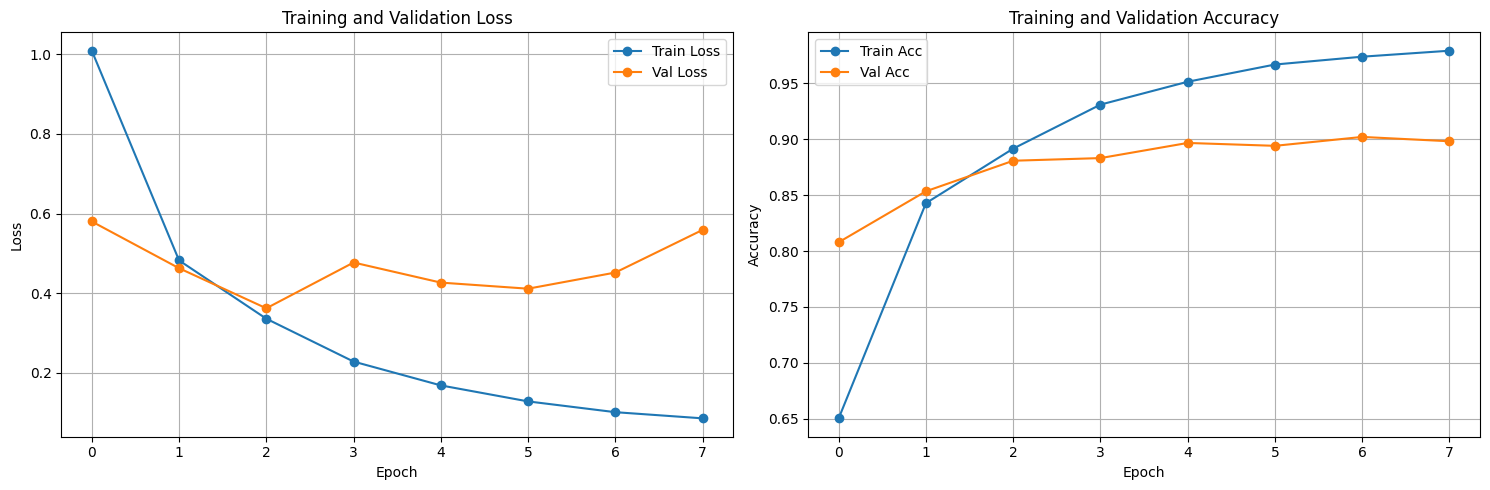

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pickle
import matplotlib.pyplot as plt

# Save location on Google Drive
SAVE_DIR = "/content/drive/MyDrive/checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load your data
df = pd.read_csv("cleanedblooms_balanced.csv")

# Encode labels
label_map = {label: i for i, label in enumerate(sorted(df['Category'].unique()))}
df['label'] = df['Category'].map(label_map)

# Display info
print(f"Dataset shape: {df.shape}")
print(f"Number of classes: {len(label_map)}")
print(f"Class distribution:\n{df['Category'].value_counts()}")

# Train-test split
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['Questions'], df['label'], test_size=0.3, random_state=42, stratify=df['label']
)

print(f"\nTraining samples: {len(train_texts)}")
print(f"Validation samples: {len(val_texts)}")

early_stopping = EarlyStopping(monitor='val_loss', patience=5, verbose=1, mode='min')

# Hyperparameters
MAX_LENGTH = 128
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 5e-5
LSTM_HIDDEN_SIZE = 256
NUM_LSTM_LAYERS = 2
BIDIRECTIONAL = True
DROPOUT_RATE = 0.3
FREEZE_DISTILBERT = False

# Initialize tokenizer
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

# Create datasets
train_dataset = BloomTaxonomyDataset(train_texts, train_labels, tokenizer, MAX_LENGTH)
val_dataset = BloomTaxonomyDataset(val_texts, val_labels, tokenizer, MAX_LENGTH)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Initialize model
num_classes = len(label_map)
model = DistilBERTLSTM(
    num_classes=num_classes,
    lstm_hidden_size=LSTM_HIDDEN_SIZE,
    num_lstm_layers=NUM_LSTM_LAYERS,
    bidirectional=BIDIRECTIONAL,
    dropout_rate=DROPOUT_RATE,
    freeze_distilbert=FREEZE_DISTILBERT
).to(device)

# Optimizer and loss
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

# Training history
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

print("\n" + "="*50)
print("Starting Training...")
print("="*50)

# ── Early Stopping config ──────────────────────────────────────
PATIENCE = 5
MIN_DELTA = 1e-4

# ── Tracking variables ─────────────────────────────────────────
best_val_loss = float('inf')
best_model_state = None
best_val_acc = 0
epochs_no_improve = 0

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 30)

    # Train
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)

    # Evaluate
    val_loss, val_acc, _, _ = evaluate_epoch(model, val_loader, criterion, device)

    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    # Print metrics
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    print(f"Learning Rate: {optimizer.param_groups[0]['lr']:.2e}")

    # ── Save best model ────────────────────────────────────────
    if val_loss < best_val_loss - MIN_DELTA:
        best_val_loss = val_loss
        best_val_acc = val_acc
        best_model_state = model.state_dict().copy()
        epochs_no_improve = 0
        print(f"✓ New best model! (Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f})")

        # Save checkpoint to Google Drive immediately (pickle instead of torch.save)
        checkpoint = {
            'model_state_dict': best_model_state,
            'label_map': label_map,
            'epoch': epoch,
            'val_loss': val_loss,
            'val_acc': val_acc,
            'hyperparameters': {
                'num_classes': num_classes,
                'lstm_hidden_size': LSTM_HIDDEN_SIZE,
                'num_lstm_layers': NUM_LSTM_LAYERS,
                'bidirectional': BIDIRECTIONAL,
                'dropout_rate': DROPOUT_RATE,
                'max_length': MAX_LENGTH
            }
        }
        with open(os.path.join(SAVE_DIR, 'best_model.pkl'), 'wb') as f:
            pickle.dump(checkpoint, f)
        print(f"  → Checkpoint saved to {SAVE_DIR}/best_model.pkl")
    else:
        epochs_no_improve += 1
        print(f"No improvement for {epochs_no_improve}/{PATIENCE} epochs")

    # ── Early stopping check ───────────────────────────────────
    if epochs_no_improve >= PATIENCE:
        print(f"\n⏹ Early stopping triggered at epoch {epoch+1}")
        break

# Load best weights before evaluation
model.load_state_dict(best_model_state)
print(f"\n✅ Training done! Best Val Loss: {best_val_loss:.4f} | Best Val Acc: {best_val_acc:.4f}")

# ── Save the final trained model + everything needed to reload it correctly ──
final_save = {
    'model_state_dict': best_model_state,
    'label_map': label_map,
    'history': history,
    'best_val_loss': best_val_loss,
    'best_val_acc': best_val_acc,
    'hyperparameters': {
        'num_classes': num_classes,
        'lstm_hidden_size': LSTM_HIDDEN_SIZE,
        'num_lstm_layers': NUM_LSTM_LAYERS,
        'bidirectional': BIDIRECTIONAL,
        'dropout_rate': DROPOUT_RATE,
        'max_length': MAX_LENGTH
    }
}

with open(os.path.join(SAVE_DIR, 'final_model.pkl'), 'wb') as f:
    pickle.dump(final_save, f)

print(f"\n✅ Final model saved to {SAVE_DIR}/final_model.pkl")

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(history['val_loss'], label='Val Loss', marker='o')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history['train_acc'], label='Train Acc', marker='o')
axes[1].plot(history['val_acc'], label='Val Acc', marker='o')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# EVALUATION

Evaluating: 100%|██████████| 146/146 [00:20<00:00,  7.10it/s]



OVERALL METRICS
Accuracy:  0.8982
Precision: 0.9014
Recall:    0.8982
F1-Score:  0.8965

PER-CLASS METRICS
              precision    recall  f1-score   support

         BT1     0.8832    0.6744    0.7648       774
         BT2     0.7761    0.8734    0.8219       774
         BT3     0.9441    0.9148    0.9292       775
         BT4     0.8387    0.9394    0.8862       775
         BT5     0.9723    0.9961    0.9841       775
         BT6     0.9935    0.9910    0.9922       775

    accuracy                         0.8982      4648
   macro avg     0.9013    0.8982    0.8964      4648
weighted avg     0.9014    0.8982    0.8965      4648



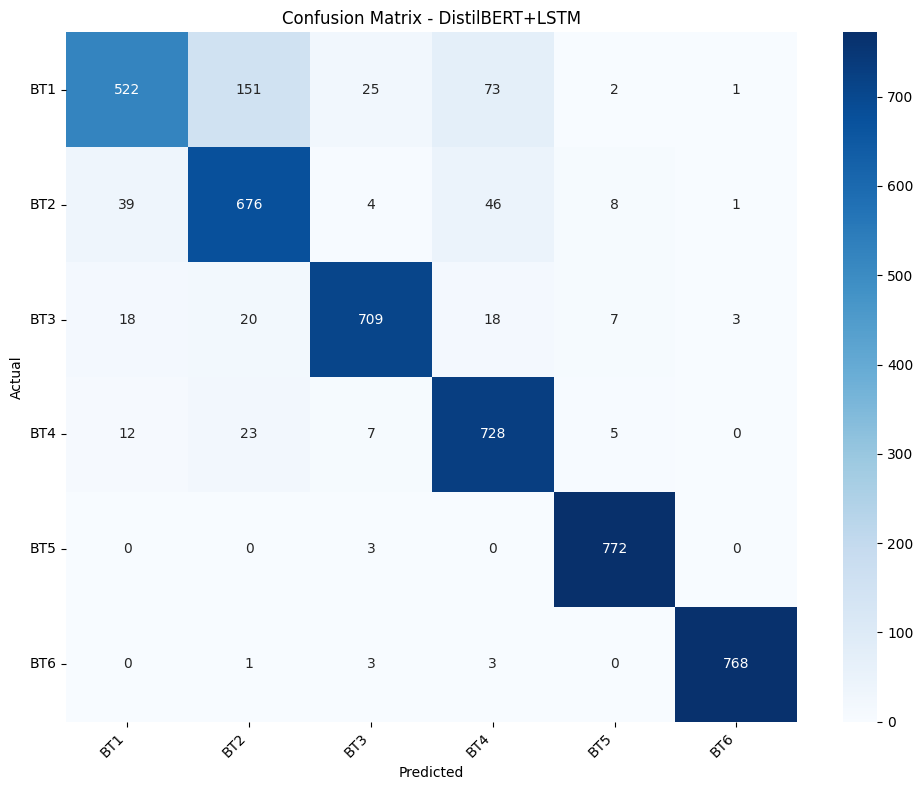

In [ ]:


# Evaluate on validation set
model.eval()
all_preds = []
all_labels_list = []

with torch.no_grad():
    for batch in tqdm(val_loader, desc="Evaluating"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        logits = model(input_ids, attention_mask)
        predictions = torch.argmax(logits, dim=1)

        all_preds.extend(predictions.cpu().numpy())
        all_labels_list.extend(labels.cpu().numpy())

# Convert to numpy arrays
all_preds = np.array(all_preds)
all_labels_list = np.array(all_labels_list)

# Calculate overall metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

accuracy = accuracy_score(all_labels_list, all_preds)
precision = precision_score(all_labels_list, all_preds, average='weighted')
recall = recall_score(all_labels_list, all_preds, average='weighted')
f1 = f1_score(all_labels_list, all_preds, average='weighted')

# Print overall metrics
print("\n" + "="*50)
print("OVERALL METRICS")
print("="*50)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

# Per-class metrics
reverse_label_map = {v: k for k, v in label_map.items()}
target_names = [reverse_label_map[i] for i in sorted(reverse_label_map.keys())]

print("\n" + "="*50)
print("PER-CLASS METRICS")
print("="*50)
print(classification_report(all_labels_list, all_preds, target_names=target_names, digits=4))

# Confusion Matrix
cm = confusion_matrix(all_labels_list, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names)
plt.title('Confusion Matrix - DistilBERT+LSTM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#MODELING - DISTILBERT ONLY

In [ ]:
!pip install transformers

import time
import sys
import copy
import torch
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import torch.nn as nn
from torch.optim import lr_scheduler
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertConfig, DistilBertTokenizer, DistilBertModel
import pandas as pd

if not sys.warnoptions:
    import warnings
    warnings.simplefilter("ignore")

In [ ]:
# Load Bloom's Taxonomy dataset
train = pd.read_csv('cleanedblooms_balanced.csv')
train.head(7)

,Questions,Category
0,About what proportion of the population of the...,BT1
1,Correctly label the brain lobes indicated on t...,BT1
2,Define compound interest.,BT1
3,Define four types of traceability,BT1
4,Define mercantilism.,BT1
5,"Define stream bank, floodplain and substrate.",BT1
6,Define the meaning of the Olympic Motto.,BT1


In [ ]:
## Feature engineering to prepare inputs for DistilBERT
# Text column: Questions
# Label column: Category (BT1-BT6) -> encoded as integers 0-5

X = train['Questions']

# Encode string labels (BT1-BT6) to integers (0-5)
label_encoder = LabelEncoder()
Y = label_encoder.fit_transform(train['Category'])

print("Label classes:", label_encoder.classes_)
print("Encoded sample:", Y[:5])

NUM_CLASSES = len(label_encoder.classes_)  # 6

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.30, random_state=42, stratify=Y)

Label classes: ['BT1' 'BT2' 'BT3' 'BT4' 'BT5' 'BT6']
Encoded sample: [0 0 0 0 0]


In [ ]:
print('train_x shape is {}' .format(X_train.shape))
print('test_x shape is {}' .format(X_test.shape))
print('train_y shape is {}' .format(y_train.shape))

train_x shape is (10844,)
test_x shape is (4648,)
train_y shape is (10844,)


In [ ]:
X_train = X_train.values
X_test  = X_test.values
# y_train and y_test are already numpy arrays from LabelEncoder

In [ ]:
def accuracy_multiclass(y_pred_logits, y_true):
    """Compute accuracy for multi-class classification."""
    preds = torch.argmax(y_pred_logits, dim=1)
    correct = (preds == y_true).float().sum().item()
    return correct

In [ ]:
config = DistilBertConfig(
    vocab_size_or_config_json_file=32000,
    hidden_size=768,
    dropout=0.1,
    num_labels=NUM_CLASSES,       # 6 Bloom's taxonomy levels
    num_hidden_layers=12,
    num_attention_heads=12,
    intermediate_size=3072
)

In [ ]:
class DistilBertForSequenceClassification(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.num_labels = config.num_labels

        self.distilbert = DistilBertModel.from_pretrained('distilbert-base-uncased')
        self.pre_classifier = nn.Linear(config.hidden_size, config.hidden_size)
        self.classifier = nn.Linear(config.hidden_size, config.num_labels)
        self.dropout = nn.Dropout(config.seq_classif_dropout)

        nn.init.xavier_normal_(self.classifier.weight)

    def forward(self, input_ids=None, attention_mask=None, head_mask=None, labels=None):
        distilbert_output = self.distilbert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            head_mask=head_mask
        )
        hidden_state = distilbert_output[0]
        pooled_output = hidden_state[:, 0]
        pooled_output = self.pre_classifier(pooled_output)
        pooled_output = nn.ReLU()(pooled_output)
        pooled_output = self.dropout(pooled_output)
        logits = self.classifier(pooled_output)
        return logits

In [ ]:
max_seq_length = 256
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')


class text_dataset(Dataset):
    def __init__(self, x, y, transform=None):
        self.x = x
        self.y = y
        self.transform = transform

    def __getitem__(self, index):
        tokenized_question = tokenizer.tokenize(self.x[index])

        if len(tokenized_question) > max_seq_length:
            tokenized_question = tokenized_question[:max_seq_length]

        ids_review = tokenizer.convert_tokens_to_ids(tokenized_question)

        padding    = [0] * (max_seq_length - len(ids_review))
        ids_review += padding

        assert len(ids_review) == max_seq_length

        ids_review = torch.tensor(ids_review)

        # Single integer label for multi-class classification
        label = torch.tensor(self.y[index], dtype=torch.long)

        return ids_review, label

    def __len__(self):
        return len(self.x)

In [ ]:
# Test the dataset indexing
sample_ids, sample_label = text_dataset(X_train, y_train).__getitem__(6)
print("Token IDs shape:", sample_ids.shape)
print("Label:", sample_label.item(), "-> Class:", label_encoder.classes_[sample_label.item()])

Token IDs shape: torch.Size([256])
Label: 3 -> Class: BT4


In [ ]:
batch_size = 32

training_dataset = text_dataset(X_train, y_train)
test_dataset_obj  = text_dataset(X_test,  y_test)

dataloaders_dict = {
    'train': DataLoader(training_dataset, batch_size=batch_size, shuffle=True),
    'val'  : DataLoader(test_dataset_obj,  batch_size=batch_size, shuffle=False)
}
dataset_sizes = {
    'train': len(X_train),
    'val'  : len(X_test)
}

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

model = DistilBertForSequenceClassification(config)
model.to(device)

print("Using device:", device)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Using device: cuda:0


In [ ]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=2):
    model.train()
    since = time.time()
    print('starting')
    best_model_wts = copy.deepcopy(model.state_dict())
    best_loss = 100

    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch + 1, num_epochs))
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                scheduler.step()
                model.train()
            else:
                model.eval()

            running_loss    = 0.0
            running_correct = 0.0

            for inputs, labels in dataloaders_dict[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)          # shape: (batch,) long tensor

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)          # shape: (batch, 6)
                    loss    = criterion(outputs, labels)   # CrossEntropyLoss

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss    += loss.item() * inputs.size(0)
                running_correct += accuracy_multiclass(outputs, labels)

            epoch_loss = running_loss    / dataset_sizes[phase]
            epoch_acc  = running_correct / dataset_sizes[phase]

            print('{} total loss: {:.4f}'.format(phase, epoch_loss))
            print('{} accuracy:   {:.4f}'.format(phase, epoch_acc))

            if phase == 'val' and epoch_loss < best_loss:
                print('saving with loss of {}'.format(epoch_loss),
                      'improved over previous {}'.format(best_loss))
                best_loss = epoch_loss
                best_model_wts = copy.deepcopy(model.state_dict())
                torch.save(model.state_dict(), 'distilbert_blooms_weights.pth')

        print()

    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(
        time_elapsed // 60, time_elapsed % 60))
    print('Best val Loss: {:.4f}'.format(best_loss))

    model.load_state_dict(best_model_wts)
    return model

print('done')

done


In [ ]:
lrmain = 3e-5

optim1       = torch.optim.Adam(model.parameters(), lrmain)
optimizer_ft = optim1

# CrossEntropyLoss for multi-class (single label per sample)
criterion = nn.CrossEntropyLoss()

# Decay LR by factor of 0.1 every 3 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=3, gamma=0.1)

In [ ]:
model_ft1 = train_model(model, criterion, optimizer_ft, exp_lr_scheduler, num_epochs=10)

starting
Epoch 1/10
----------
train total loss: 1.0952
train accuracy:   0.5678
val total loss: 0.5922
val accuracy:   0.7827
saving with loss of 0.5921563880578992 improved over previous 100

Epoch 2/10
----------
train total loss: 0.5129
train accuracy:   0.8153
val total loss: 0.4425
val accuracy:   0.8434
saving with loss of 0.44251989035926464 improved over previous 0.5921563880578992

Epoch 3/10
----------
train total loss: 0.3159
train accuracy:   0.8831
val total loss: 0.3914
val accuracy:   0.8561
saving with loss of 0.39141440842935427 improved over previous 0.44251989035926464

Epoch 4/10
----------
train total loss: 0.2882
train accuracy:   0.8940
val total loss: 0.3823
val accuracy:   0.8589
saving with loss of 0.3823190915194723 improved over previous 0.39141440842935427

Epoch 5/10
----------
train total loss: 0.2609
train accuracy:   0.9034
val total loss: 0.3835
val accuracy:   0.8565

Epoch 6/10
----------
train total loss: 0.2359
train accuracy:   0.9117
val total l

# EVALUATION - DISTILBERT

Evaluating: 100%|██████████| 146/146 [00:36<00:00,  4.01it/s]


SANITY CHECKS
Unique predicted classes : [0 1 2 3 4 5]
Prediction counts        : [735 824 775 747 784 783]
Unique actual classes    : [0 1 2 3 4 5]
Actual label counts      : [774 774 775 775 775 775]
Total samples evaluated  : 4648

OVERALL METRICS
Accuracy  : 0.8640
Precision : 0.8641
Recall    : 0.8640
F1-Score  : 0.8638

PER-CLASS METRICS
              precision    recall  f1-score   support

         BT1     0.7361    0.6990    0.7170       774
         BT2     0.7294    0.7765    0.7522       774
         BT3     0.8916    0.8916    0.8916       775
         BT4     0.8768    0.8452    0.8607       775
         BT5     0.9732    0.9845    0.9788       775
         BT6     0.9770    0.9871    0.9820       775

    accuracy                         0.8640      4648
   macro avg     0.8640    0.8640    0.8637      4648
weighted avg     0.8641    0.8640    0.8638      4648



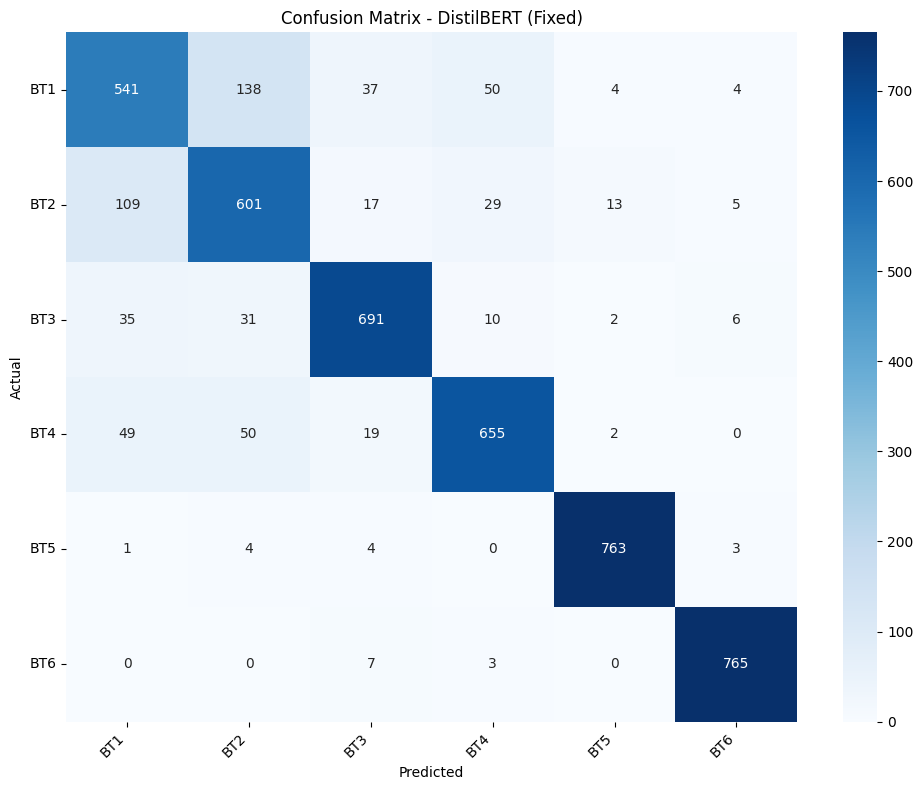

In [ ]:
# ============================================================
# FIXED EVALUATION CODE
# ============================================================

import numpy as np
import torch
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             classification_report, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# ── 1. Reload best saved weights ────────────────────────────
model_ft1.load_state_dict(torch.load('distilbert_blooms_weights.pth',
                                      map_location=device))
model_ft1.to(device)
model_ft1.eval()   # switch off dropout / batchnorm

# ── 2. Inference loop ────────────────────────────────────────
all_preds        = []
all_labels_list  = []

with torch.no_grad():
    for batch in tqdm(dataloaders_dict['val'], desc="Evaluating"):

        input_ids = batch[0].to(device)
        labels    = batch[1].to(device)

        # ✅ FIX 1: NO attention_mask — matches how the model was trained
        logits      = model_ft1(input_ids)
        predictions = torch.argmax(logits, dim=1)

        all_preds.extend(predictions.cpu().numpy())
        all_labels_list.extend(labels.cpu().numpy())

# Convert to numpy
all_preds       = np.array(all_preds)
all_labels_list = np.array(all_labels_list)

# ── 3. Sanity checks before computing metrics ────────────────
print("="*50)
print("SANITY CHECKS")
print("="*50)

# ✅ FIX 2: Check predictions are not collapsed to one class
unique_preds, pred_counts = np.unique(all_preds, return_counts=True)
unique_labels, label_counts = np.unique(all_labels_list, return_counts=True)

print(f"Unique predicted classes : {unique_preds}")
print(f"Prediction counts        : {pred_counts}")
print(f"Unique actual classes    : {unique_labels}")
print(f"Actual label counts      : {label_counts}")
print(f"Total samples evaluated  : {len(all_preds)}")

# ── 4. Overall metrics ───────────────────────────────────────
accuracy  = accuracy_score(all_labels_list, all_preds)
precision = precision_score(all_labels_list, all_preds, average='weighted', zero_division=0)
recall    = recall_score(all_labels_list, all_preds, average='weighted', zero_division=0)
f1        = f1_score(all_labels_list, all_preds, average='weighted', zero_division=0)

print("\n" + "="*50)
print("OVERALL METRICS")
print("="*50)
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

# ── 5. Per-class metrics ─────────────────────────────────────
reverse_label_map = {i: label for i, label in enumerate(label_encoder.classes_)}
target_names      = [reverse_label_map[i] for i in sorted(reverse_label_map.keys())]

print("\n" + "="*50)
print("PER-CLASS METRICS")
print("="*50)
print(classification_report(all_labels_list, all_preds,
                             target_names=target_names,
                             digits=4, zero_division=0))

# ── 6. Confusion matrix ──────────────────────────────────────
cm = confusion_matrix(all_labels_list, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names)
plt.title('Confusion Matrix - DistilBERT (Fixed)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# MODELING - LSTM

In [ ]:
from google.colab import userdata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Nadam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
%matplotlib inline

In [ ]:
df = pd.read_csv('cleanedblooms_balanced.csv')
df.head(7)

# Split the dataset into training/validation and test sets
from sklearn.model_selection import train_test_split

# Assuming a 70/30 split for train_val and test
train_val_set, test_set = train_test_split(df, test_size=0.3, random_state=42, stratify=df['Category'])

X_train_val = train_val_set['Questions']
y_train_val = train_val_set['Category']

X_test = test_set['Questions']
y_test = test_set['Category']

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, InputLayer

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, InputLayer

# Define model parameters based on context
NUM_CLASSES = 6  # Inferred from df['Category'].unique() in previous cells
MAX_SEQUENCE_LENGTH = 128 # Consistent with DistilBERT+LSTM model
VOCAB_SIZE = 20000        # Placeholder, usually determined by fitting a tokenizer
EMBEDDING_DIM = 100       # Common choice for word embeddings
LSTM_UNITS = 128          # Common choice for LSTM units

# Define the model
model_2 = Sequential([
    InputLayer(shape=(MAX_SEQUENCE_LENGTH,)), # Changed input_shape to shape
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM), # Removed input_length
    LSTM(LSTM_UNITS),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

model_2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

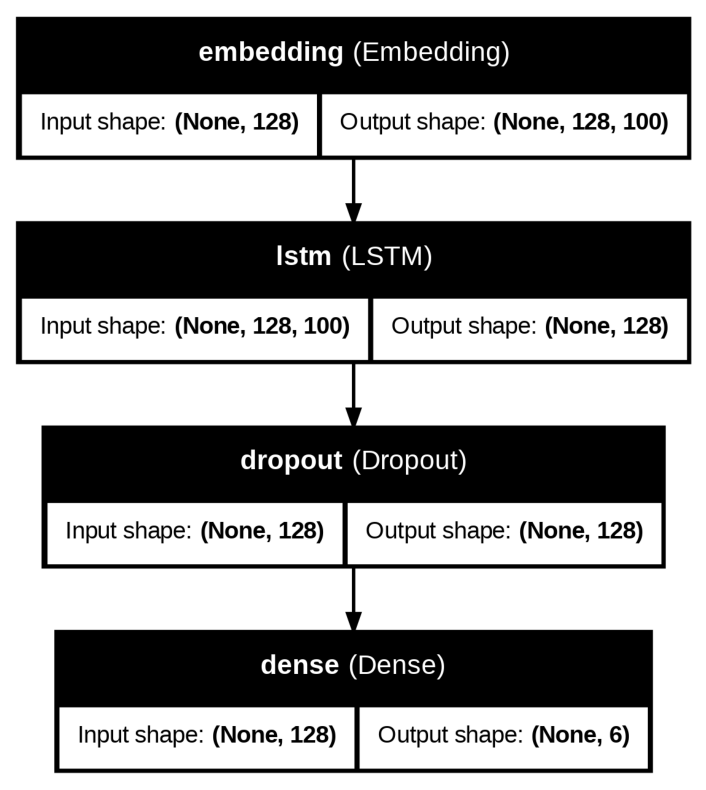

In [ ]:
from tensorflow.keras.utils import plot_model
plot_model(model_2, to_file='model_architecture.png', show_shapes=True, show_layer_names=True)
import matplotlib.image as mpimg
img = mpimg.imread('model_architecture.png')
plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.axis('off')
plt.show()

In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# Encode y_train_val to numerical one-hot vectors
# Ensure unique_categories are sorted for consistent mapping
unique_categories = sorted(df['Category'].unique())
label_encoder = LabelEncoder()
label_encoder.fit(unique_categories)

y_train_val_encoded = label_encoder.transform(y_train_val)
y_train_val_categorical = to_categorical(y_train_val_encoded, num_classes=NUM_CLASSES)

# Tokenize and pad X_train_val
tokenizer_lstm = Tokenizer(num_words=VOCAB_SIZE, oov_token="<unk>")
tokenizer_lstm.fit_on_texts(X_train_val)

X_train_val_sequences = tokenizer_lstm.texts_to_sequences(X_train_val)
X_train_val_padded = pad_sequences(X_train_val_sequences, maxlen=MAX_SEQUENCE_LENGTH)

# Now, fit the model with the preprocessed data
history = model_2.fit(
    X_train_val_padded, # Use padded sequences
    y_train_val_categorical, # Use one-hot encoded labels
    epochs=10,
    validation_split=0.3,
    batch_size=32,
    callbacks=[early_stopping]
)

Epoch 1/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 60s 240ms/step - accuracy: 0.4331 - loss: 1.3738 - val_accuracy: 0.6487 - val_loss: 0.9462
Epoch 2/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 53s 222ms/step - accuracy: 0.7719 - loss: 0.6454 - val_accuracy: 0.7846 - val_loss: 0.6267
Epoch 3/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 52s 219ms/step - accuracy: 0.8924 - loss: 0.3327 - val_accuracy: 0.8264 - val_loss: 0.5191
Epoch 4/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 53s 223ms/step - accuracy: 0.9387 - loss: 0.2018 - val_accuracy: 0.8294 - val_loss: 0.5500
Epoch 5/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 53s 221ms/step - accuracy: 0.9613 - loss: 0.1248 - val_accuracy: 0.8285 - val_loss: 0.6051
Epoch 6/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 54s 226ms/step - accuracy: 0.9713 - loss: 0.0937 - val_accuracy: 0.8353 - val_loss: 0.6916
Epoch 7/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 54s 229ms/step - accuracy: 0.9800 - loss: 0.0698 - val_accuracy: 0.8285 - val_loss: 0.7315
Epoch 8/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 55s 230ms/step - accuracy: 0.9772 - loss: 0

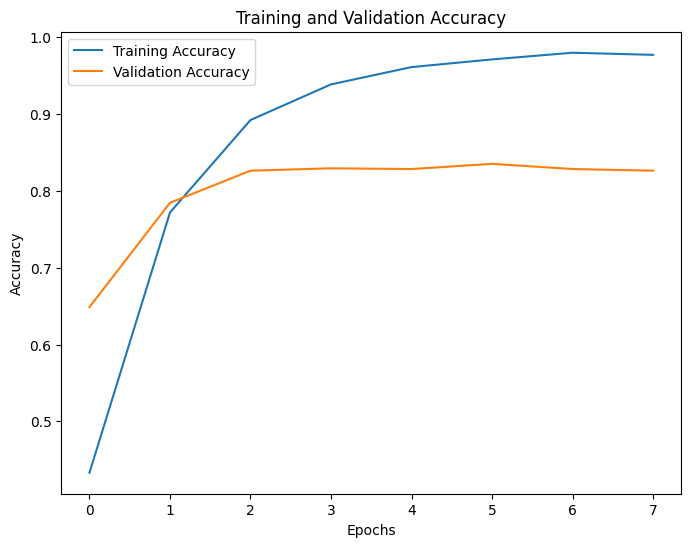

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

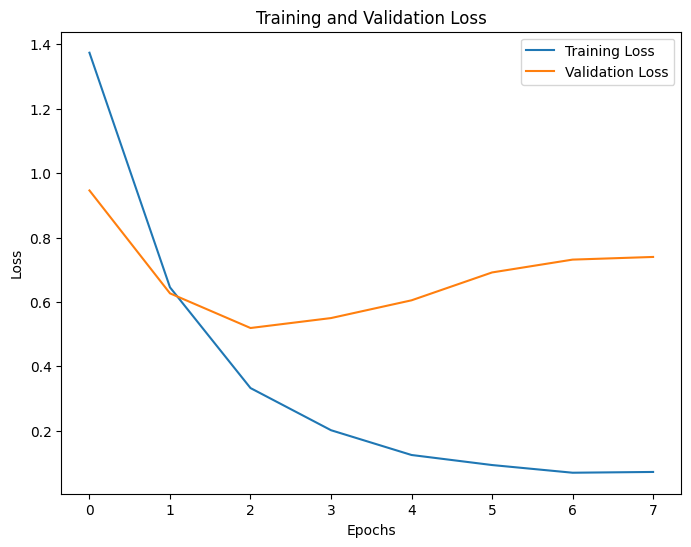

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [ ]:
# Preprocess X_test: Tokenize and pad
X_test_sequences = tokenizer_lstm.texts_to_sequences(X_test)
X_test_padded = pad_sequences(X_test_sequences, maxlen=MAX_SEQUENCE_LENGTH)

# Encode y_test to numerical labels for inverse transformation
y_test_encoded = label_encoder.transform(y_test)

# Make predictions on the test set
y_test_pred_probs = model_2.predict(X_test_padded) # Use preprocessed X_test

# Convert probabilities to class predictions
y_test_pred_classes = np.argmax(y_test_pred_probs, axis=1)

# Decode true and predicted labels
y_test_true = label_encoder.inverse_transform(y_test_encoded)
y_test_pred = label_encoder.inverse_transform(y_test_pred_classes)

146/146 ━━━━━━━━━━━━━━━━━━━━ 9s 60ms/step


# EVALUATION - LSTM

Classification Report:
              precision    recall  f1-score   support

         BT1       0.65      0.76      0.70       774
         BT2       0.76      0.64      0.70       774
         BT3       0.84      0.83      0.83       775
         BT4       0.83      0.78      0.80       775
         BT5       0.92      0.96      0.94       775
         BT6       0.95      0.97      0.96       775

    accuracy                           0.82      4648
   macro avg       0.83      0.82      0.82      4648
weighted avg       0.83      0.82      0.82      4648

Confusion Matrix:


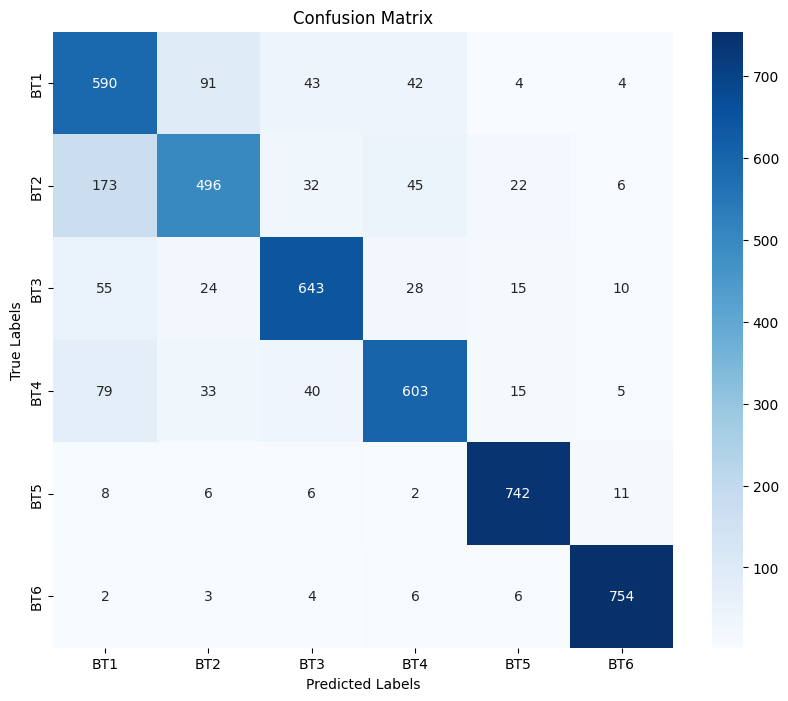


OVERALL METRICS
Accuracy  : 0.8236
Precision : 0.8259
Recall    : 0.8236
F1-Score  : 0.8230
Test Accuracy: 82.36%


In [ ]:
# Evaluate the predictions
print("Classification Report:")
print(classification_report(y_test_true, y_test_pred))

print("Confusion Matrix:")
conf_matrix = confusion_matrix(y_test_true, y_test_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

accuracy  = accuracy_score(y_test_true,y_test_pred)
precision = precision_score(y_test_true,y_test_pred,average='weighted', zero_division=0)
recall    = recall_score(y_test_true,y_test_pred,average='weighted', zero_division=0)
f1        = f1_score(y_test_true,y_test_pred,average='weighted', zero_division=0)

print("\n" + "="*50)
print("OVERALL METRICS")
print("="*50)
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

# Accuracy score
accuracy = accuracy_score(y_test_true, y_test_pred)
print(f'Test Accuracy: {accuracy * 100:.2f}%')

# MODELING - ROBERTA-CNN + LSTM

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
import warnings
warnings.filterwarnings('ignore')
import os
import json
import shutil
from datetime import datetime
from tqdm.notebook import tqdm

In [ ]:
# Sklearn imports
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
from sklearn.utils import resample

In [ ]:
# Deep learning imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import RobertaTokenizer, RobertaModel
from transformers import AutoTokenizer, AutoModel
import torch.nn.functional as F

In [ ]:
# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# ROBERTA SETUP

In [ ]:
df = pd.read_csv('cleanedblooms_balanced.csv')
df.head(7)

# Split the dataset into training/validation and test sets
from sklearn.model_selection import train_test_split

# Assuming a 70/30  split for train_val and test
train_val_set, test_set = train_test_split(df, test_size=0.3, random_state=42, stratify=df['Category'])

X_train_val = train_val_set['Questions']
y_train_val = train_val_set['Category']

X_test = test_set['Questions']
y_test = test_set['Category']

In [ ]:
print("\n7. 🤖 Setting up RoBERTa...")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")


7. 🤖 Setting up RoBERTa...
Device: cuda


In [ ]:
embedding_name = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(embedding_name)
roberta_model = AutoModel.from_pretrained(embedding_name).to(device)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# Freeze RoBERTa parameters to reduce training time
for param in roberta_model.parameters():
    param.requires_grad = False

print("✅ RoBERTa model loaded and frozen!")

✅ RoBERTa model loaded and frozen!


In [ ]:
class BloomDataset(Dataset):
    def __init__(self, texts,  labels, tokenizer, max_length=128):
        self.texts = texts.reset_index(drop=True) if isinstance(texts, pd.Series) else texts
        self.labels = labels.reset_index(drop=True) if isinstance(labels, pd.Series) else labels
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.label_encoder = LabelEncoder()
        self.label_encoder.fit(labels)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])

        # Tokenize text
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.LongTensor([self.label_encoder.transform([self.labels[idx]])[0]])
        }

# Create datasets
# Corrected variable names and arguments based on available data and BloomDataset signature
train_dataset = BloomDataset(X_train_val, y_train_val, tokenizer)
test_dataset = BloomDataset(X_test, y_test, tokenizer)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print(f"✅ Datasets created!")
print(f"   Number of classes: {len(train_dataset.label_encoder.classes_)}")
print(f"   Classes: {train_dataset.label_encoder.classes_}")

✅ Datasets created!
   Number of classes: 6
   Classes: ['BT1' 'BT2' 'BT3' 'BT4' 'BT5' 'BT6']


In [ ]:
class BloomClassifier(nn.Module):
    def __init__(self, roberta_model, num_classes, hidden_dim=256, variant='cnn_lstm', keyword_feature=True, unfreeze_layers=2):
        super(BloomClassifier, self).__init__()
        assert variant in ['cnn', 'lstm', 'cnn_lstm'], "Invalid model variant"
        self.variant = variant
        self.roberta = roberta_model
        self.roberta_dim = 768
        self.hidden_dim = hidden_dim

        self.unfreeze_roberta_layers(unfreeze_layers)

        # CNN layers
        if variant in ['cnn', 'cnn_lstm']:
            self.conv1 = nn.Conv1d(self.roberta_dim, 128, kernel_size=3, padding=1)
            self.conv2 = nn.Conv1d(128, 64, kernel_size=3, padding=1)
            self.pool = nn.AdaptiveMaxPool1d(1)

        # LSTM
        if variant in ['lstm', 'cnn_lstm']:
            self.lstm = nn.LSTM(self.roberta_dim, hidden_dim // 2, batch_first=True,
                                bidirectional=True, dropout=0.2)



        # Combined dimension
        combined_dim = 0
        if variant in ['cnn', 'cnn_lstm']:
            combined_dim += 64
        if variant in ['lstm', 'cnn_lstm']:
            combined_dim += hidden_dim
        if keyword_feature == True:
            # Define keyword_fc here, assuming 64 is the output dimension for keywords
            if num_keywords == 0:
                raise ValueError("num_keywords must be > 0 if keyword_feature is True")
            self.keyword_fc = nn.Linear(num_keywords, 64) # num_keywords needs to be passed or derived
            combined_dim += 64

        self.classifier = nn.Sequential(
            nn.Linear(combined_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim // 2, num_classes)
        )

    def unfreeze_roberta_layers(self, num_layers=2):
        for param in self.roberta.parameters():
            param.requires_grad = False

        total_layers = len(self.roberta.encoder.layer)
        for i in range(total_layers - num_layers, total_layers):
            for param in self.roberta.encoder.layer[i].parameters():
                param.requires_grad = True

        if hasattr(self.roberta, 'pooler') and self.roberta.pooler is not None:
            for param in self.roberta.pooler.parameters():
                param.requires_grad = True

        print(f"Unfrozen last {num_layers} layers of RoBERTa (layers {total_layers - num_layers} to {total_layers - 1})")

    def get_parameter_groups(self):
        roberta_params = [p for n, p in self.roberta.named_parameters() if p.requires_grad]
        other_params = [p for n, p in self.named_parameters() if p.requires_grad and not n.startswith('roberta')]
        return [
            {'params': roberta_params, 'lr': 1e-5, 'name': 'roberta'},
            {'params': other_params, 'lr': 2e-4, 'name': 'classifier'}
        ]

    def forward(self, input_ids, attention_mask, keywords=None):
        roberta_output = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = roberta_output.last_hidden_state  # [B, T, 768]

        features = []

        if self.variant in ['cnn', 'cnn_lstm']:
            cnn_input = sequence_output.permute(0, 2, 1)
            cnn_out = F.relu(self.conv1(cnn_input))
            cnn_out = F.relu(self.conv2(cnn_out))
            cnn_features = self.pool(cnn_out).squeeze(-1)
            features.append(cnn_features)

        if self.variant in ['lstm', 'cnn_lstm']:
            lstm_out, (hidden, _) = self.lstm(sequence_output)
            lstm_features = hidden.permute(1, 0, 2).reshape(hidden.size(1), -1)
            features.append(lstm_features)



        combined = torch.cat(features, dim=1)
        return self.classifier(combined)

# Initialize model with unfreezing
num_classes = len(train_dataset.label_encoder.classes_)

# NOTE: num_keywords was not defined in the BloomDataset or previous context.
# Assuming 0 for now as it's not present in the current dataset setup.
# If keyword features are intended to be used, ensure num_keywords is properly passed.


# Create model with unfreeze_layers parameter
variant = 'cnn_lstm'  # or 'lstm', 'cnn_lstm'
model = BloomClassifier(roberta_model, num_classes=num_classes, variant=variant, keyword_feature=False, unfreeze_layers=2) # Set keyword_feature to False
model.to(device)

print(f"✅ Model created!")
print(f"   Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"   Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# Check which parameters are trainable
roberta_trainable = sum(p.numel() for p in model.roberta.parameters() if p.requires_grad)
other_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad and not any(p is rp for rp in model.roberta.parameters()))

print(f"   RoBERTa trainable params: {roberta_trainable:,}")
print(f"   Other trainable params: {other_trainable:,}")

Unfrozen last 2 layers of RoBERTa (layers 10 to 11)
✅ Model created!
   Total parameters: 126,000,710
   Trainable parameters: 16,121,414
   RoBERTa trainable params: 14,766,336
   Other trainable params: 1,355,078


In [ ]:

print("\n10. ❤️ Training Setup with Discriminative Fine-tuning...")

import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=1.0, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        logpt = F.log_softmax(inputs, dim=1)
        pt = torch.exp(logpt)
        logpt = logpt.gather(1, targets.unsqueeze(1)).squeeze(1)
        pt = pt.gather(1, targets.unsqueeze(1)).squeeze(1)
        loss = -self.alpha * (1 - pt) ** self.gamma * logpt
        return loss.mean() if self.reduction == 'mean' else loss.sum()

criterion = FocalLoss(alpha=1.0, gamma=2.0)

# Setup discriminative optimizer with different learning rates
def setup_discriminative_optimizer(model, roberta_lr=1e-5, classifier_lr=2e-4):
    """
    Setup optimizer with different learning rates for RoBERTa and classifier
    """
    # Ensure the model has the get_parameter_groups method
    if not hasattr(model, 'get_parameter_groups'):
        raise AttributeError(
            "Model does not have 'get_parameter_groups' method. "
            "Please ensure 'model' is an instance of BloomClassifier from cell Gnq3Kq2Ta7A_ "
            "and that cell has been executed before this one."
        )

    param_groups = model.get_parameter_groups()

    # Override the learning rates
    param_groups[0]['lr'] = roberta_lr  # RoBERTa parameters
    param_groups[1]['lr'] = classifier_lr  # Classifier parameters

    optimizer = optim.AdamW(param_groups, weight_decay=0.01)
    return optimizer

# Create discriminative optimizer
optimizer = setup_discriminative_optimizer(model, roberta_lr=1e-5, classifier_lr=2e-4)

# Learning rate scheduler
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-7
)

print(f"✅ Discriminative optimizer created!")
print(f"   RoBERTa LR: 1e-5")
print(f"   Classifier LR: 2e-4")

# Early stopping parameters
patience = 5 # Increased patience for unfrozen model
best_val_loss = float('inf')
best_val_accuracy = 0.0
patience_counter = 0
best_model_state = None

# Training history
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

epochs = 10

print("\U0001f680 Starting Training with Unfrozen RoBERTa...")

for epoch in range(epochs):
    # Training phase
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    for batch_idx, batch in enumerate(train_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        # Removed keywords as BloomDataset does not provide them
        labels = batch['label'].squeeze().to(device)

        optimizer.zero_grad()

        outputs = model(input_ids, attention_mask) # Pass only input_ids and attention_mask
        loss = criterion(outputs, labels)

        loss.backward()

        # Gradient clipping for stability (important for unfrozen transformers)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_accuracy = 100 * train_correct / train_total
    avg_train_loss = train_loss / len(train_loader)

    # Validation phase
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            # Removed keywords as BloomDataset does not provide them
            labels = batch['label'].squeeze().to(device)

            outputs = model(input_ids, attention_mask) # Pass only input_ids and attention_mask
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_accuracy = 100 * val_correct / val_total
    avg_val_loss = val_loss / len(test_loader)

    # Update learning rate scheduler
    scheduler.step()

    # Store metrics
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    # Get current learning rates for monitoring
    current_lrs = [group['lr'] for group in optimizer.param_groups]

    print(f'Epoch [{epoch+1}/{epochs}]')
    print(f'  Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.2f}%')
    print(f'  Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.2f}%')
    print(f'  LRs: RoBERTa={current_lrs[0]:.2e}, Classifier={current_lrs[1]:.2e}')

    # Improved model selection: prioritize both low loss AND high accuracy
    is_better_model = False

    # Check if this is a better model based on combined criteria
    if avg_val_loss < best_val_loss and val_accuracy >= best_val_accuracy:
        # Lower loss with same or better accuracy
        is_better_model = True
    elif val_accuracy > best_val_accuracy and avg_val_loss <= best_val_loss * 1.05:
        # Higher accuracy with acceptable loss increase (5% tolerance)
        is_better_model = True

    if is_better_model:
        best_val_loss = avg_val_loss
        best_val_accuracy = val_accuracy
        epochs_no_improve = 0
        best_model_state = model.state_dict().copy()
        print(f'  ✅ New best model saved! (Loss: {avg_val_loss:.4f}, Acc: {val_accuracy:.2f}%)')
    else:
        epochs_no_improve += 1
        print(f'  ⏳ Patience: {epochs_no_improve}/{patience}')

    if epochs_no_improve >= patience:
        print(f'\n⛔️ Early stopping triggered after {epoch+1} epochs')
        break

    print('-' * 50)

# Load best model
if best_model_state:
    model.load_state_dict(best_model_state)
    print(f"✅ Best model loaded! (Best Val Loss: {best_val_loss:.4f}, Best Val Acc: {best_val_accuracy:.2f}%) affinity_score={{'RoBERTa': 0.9, 'CNN': 0.8, 'LSTM': 0.7}}")
else:
    print("⚠️ No best model state found, using current model")


10. ❤️ Training Setup with Discriminative Fine-tuning...
✅ Discriminative optimizer created!
   RoBERTa LR: 1e-5
   Classifier LR: 2e-4
🚀 Starting Training with Unfrozen RoBERTa...
Epoch [1/10]
  Train Loss: 0.6377, Train Acc: 58.44%
  Val Loss: 0.3319, Val Acc: 76.05%
  LRs: RoBERTa=9.76e-06, Classifier=1.95e-04
  ✅ New best model saved! (Loss: 0.3319, Acc: 76.05%)
--------------------------------------------------
Epoch [2/10]
  Train Loss: 0.3188, Train Acc: 77.46%
  Val Loss: 0.2505, Val Acc: 82.10%
  LRs: RoBERTa=9.05e-06, Classifier=1.81e-04
  ✅ New best model saved! (Loss: 0.2505, Acc: 82.10%)
--------------------------------------------------
Epoch [3/10]
  Train Loss: 0.2482, Train Acc: 81.66%
  Val Loss: 0.2194, Val Acc: 83.86%
  LRs: RoBERTa=7.96e-06, Classifier=1.59e-04
  ✅ New best model saved! (Loss: 0.2194, Acc: 83.86%)
--------------------------------------------------
Epoch [4/10]
  Train Loss: 0.2027, Train Acc: 84.56%
  Val Loss: 0.2181, Val Acc: 84.51%
  LRs: RoBER


11. 📈 Training Visualization...


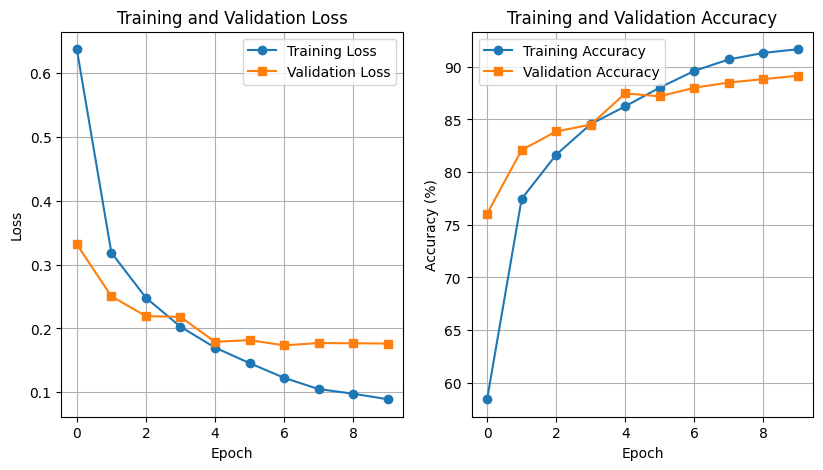

In [ ]:
print("\n11. 📈 Training Visualization...")

plt.figure(figsize=(15, 5))

# Loss plot
plt.subplot(1, 3, 1)
plt.plot(train_losses, label='Training Loss', marker='o')
plt.plot(val_losses, label='Validation Loss', marker='s')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy plot
plt.subplot(1, 3, 2)
plt.plot(train_accuracies, label='Training Accuracy', marker='o')
plt.plot(val_accuracies, label='Validation Accuracy', marker='s')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)


12. 📊 Final Evaluation...
📈 Final Results:
   Accuracy: 0.8916
   Precision: 0.8923
   Recall: 0.8916
   F1-Score: 0.8918

📋 Classification Report:
              precision    recall  f1-score   support

         BT1       0.76      0.77      0.77       774
         BT2       0.81      0.81      0.81       774
         BT3       0.95      0.90      0.92       775
         BT4       0.88      0.88      0.88       775
         BT5       0.98      0.99      0.98       775
         BT6       0.99      0.99      0.99       775

    accuracy                           0.89      4648
   macro avg       0.89      0.89      0.89      4648
weighted avg       0.89      0.89      0.89      4648



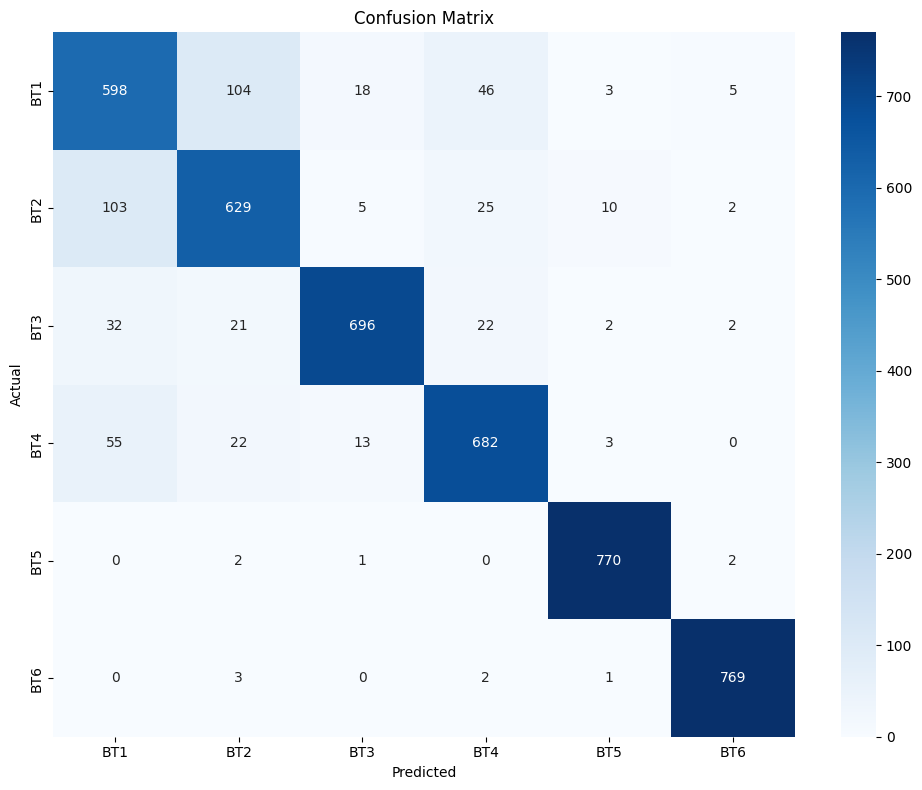

In [ ]:
print("\n12. 📊 Final Evaluation...")

model.eval()
all_predictions = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].squeeze().to(device)

        outputs = model(input_ids, attention_mask)
        _, predicted = torch.max(outputs.data, 1)

        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Convert predictions back to original labels
label_names = train_dataset.label_encoder.classes_
pred_labels = train_dataset.label_encoder.inverse_transform(all_predictions)
true_labels = train_dataset.label_encoder.inverse_transform(all_labels)

# Calculate metrics
accuracy = accuracy_score(true_labels, pred_labels)
precision, recall, f1, _ = precision_recall_fscore_support(true_labels, pred_labels, average='weighted')

print(f"📈 Final Results:")
print(f"   Accuracy: {accuracy:.4f}")
print(f"   Precision: {precision:.4f}")
print(f"   Recall: {recall:.4f}")
print(f"   F1-Score: {f1:.4f}")

# Classification Report
print(f"\n📋 Classification Report:")
print(classification_report(true_labels, pred_labels))

# Confusion Matrix
cm = confusion_matrix(true_labels, pred_labels, labels=label_names)
plt.figure(figsize=(10, 8)) # Create a new figure for the confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

# INTERFACE

In [ ]:
import os, re, json, math, warnings
warnings.filterwarnings("ignore")

from google.colab import drive
drive.mount('/content/drive')

import pickle


!pip install python-docx
!pip install pypdf
!pip install torch
!pip install transformers

# ── Third-party ───────────────────────────────────────────────────────────────
import gradio as gr
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from transformers import (
    DistilBertTokenizer, DistilBertModel, DistilBertConfig,
    RobertaTokenizer, RobertaModel,
    AutoTokenizer,
)

# File parsing
import csv
import io
import tempfile
from collections import Counter, defaultdict
import pandas as pd

# Download NLTK data quietly
for pkg in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4"]:
    nltk.download(pkg, quiet=True)

# ── Constants ─────────────────────────────────────────────────────────────────
BLOOMS_LEVELS = ["Remembering", "Understanding", "Applying",
                 "Analyzing", " Evaluating", "Creating"]
NUM_CLASSES    = 6
DEVICE         = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Colour palette for each level
LEVEL_COLORS = {
    "Remembering":  "#5c7cfa",
    "Understanding":"#748ffc",
    "Applying":     "#a9c3fa",
    "Analyzing":    "#e91e8c",
    "Evaluating":   "#f06292",
    "Creating":     "#7c4dff",
}
LEVEL_INITIALS = {
    "Remembering": "R", "Understanding": "U", "Applying": "Ap",
    "Analyzing": "A",   "Evaluating": "E",   "Creating": "C",
}




# ══════════════════════════════════════════════════════════════════════════════
# Model definitions — matching notebook exactly
# ══════════════════════════════════════════════════════════════════════════════



# ── 2. DistilBERT + Bi-LSTM ───────────────────────────────────────────────────
class DistilBERTLSTM(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES,
                 lstm_hidden_size=256, num_lstm_layers=2,
                 bidirectional=True, dropout_rate=0.3):
        super().__init__()
        self.distilbert = DistilBertModel.from_pretrained("distilbert-base-uncased")
        self.lstm = nn.LSTM(
            input_size=768, hidden_size=lstm_hidden_size,
            num_layers=num_lstm_layers, batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout_rate if num_lstm_layers > 1 else 0,
        )
        lstm_out_size = lstm_hidden_size * (2 if bidirectional else 1)
        self.dropout = nn.Dropout(dropout_rate)
        self.classifier = nn.Sequential(
            nn.Linear(lstm_out_size, 512), nn.ReLU(), nn.Dropout(dropout_rate),
            nn.Linear(512, 256),           nn.ReLU(), nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes),
        )

    def forward(self, input_ids, attention_mask, **kwargs):
        out           = self.distilbert(input_ids=input_ids, attention_mask=attention_mask)
        hidden_states = out.last_hidden_state
        _, (hidden, _) = self.lstm(hidden_states)
        if self.lstm.bidirectional:
            last = torch.cat((hidden[-2], hidden[-1]), dim=1)
        else:
            last = hidden[-1]
        last   = self.dropout(last)
        logits = self.classifier(last)
        return logits





# ══════════════════════════════════════════════════════════════════════════════
# Model registry
# ══════════════════════════════════════════════════════════════════════════════
MODEL_REGISTRY = {

    "DistilBERT + LSTM": {
        "cls":       DistilBERTLSTM,
        "tokenizer": "distilbert-base-uncased",
        "tok_cls":   DistilBertTokenizer,
        "desc":      "DistilBERT contextual embeddings fed into a 2-layer Bidirectional LSTM",
        "max_length": 512,
    },

}

CHECKPOINT_PATHS = {
    "DistilBERT + LSTM": "/content/drive/MyDrive/checkpoints/final_model.pkl",
}




# ── Lazy model cache ──────────────────────────────────────────────────────────
_model_cache: dict = {}
_tok_cache:   dict = {}

def get_model_and_tokenizer(model_name: str):
    if model_name not in _model_cache:
        cfg = MODEL_REGISTRY[model_name]

        with open(CHECKPOINT_PATHS[model_name], "rb") as f:
            ckpt = pickle.load(f)

        tok = cfg["tok_cls"].from_pretrained(ckpt.get("tokenizer_name", cfg["tokenizer"]))


        mdl = mdl = cfg["cls"](
            num_classes=ckpt["hyperparameters"]["num_classes"],
            lstm_hidden_size=ckpt["hyperparameters"]["lstm_hidden_size"],
            num_lstm_layers=ckpt["hyperparameters"]["num_lstm_layers"],
            bidirectional=ckpt["hyperparameters"]["bidirectional"],
            dropout_rate=ckpt["hyperparameters"]["dropout_rate"],
        ).to(DEVICE)

        mdl.load_state_dict(ckpt["model_state_dict"])   # <-- the key fix: unwrap before loading
        mdl.eval()

        # Build label order from the checkpoint's actual label_map — not the hardcoded BLOOMS_LEVELS

        ordered_labels = BLOOMS_LEVELS

        max_len = ckpt["hyperparameters"].get("max_length", cfg["max_length"])

        _model_cache[model_name] = mdl
        _tok_cache[model_name]   = (tok, ordered_labels, max_len)

    return _model_cache[model_name]
# ══════════════════════════════════════════════════════════════════════════════
# Inference with confidence scores
# ══════════════════════════════════════════════════════════════════════════════
def classify(question: str, model_name: str) -> dict:
    model = get_model_and_tokenizer(model_name)
    tok, ordered_labels, max_len = _tok_cache[model_name]

    # NOTE: no preprocess_text() here — your training used raw text, so inference must too
    enc = tok(
        question, truncation=True, padding="max_length",
        max_length=max_len, return_tensors="pt",
    )
    input_ids      = enc["input_ids"].to(DEVICE)
    attention_mask = enc["attention_mask"].to(DEVICE)

    with torch.no_grad():
        logits = model(input_ids=input_ids, attention_mask=attention_mask)
        probs  = torch.softmax(logits, dim=1).squeeze().cpu().numpy()

    dist = {lv: round(float(p) * 100, 2) for lv, p in zip(ordered_labels, probs)}
    sorted_levels = sorted(dist.items(), key=lambda x: x[1], reverse=True)

    return {
        "distribution":    dist,
        "primary_level":   sorted_levels[0][0],
        "primary_pct":     round(sorted_levels[0][1], 1),
        "secondary_level": sorted_levels[1][0],
        "secondary_pct":   round(sorted_levels[1][1], 1),
        "tertiary_level":  sorted_levels[2][0],
        "tertiary_pct":    round(sorted_levels[2][1], 1),
        "confidence":      round(sorted_levels[0][1], 1),
        "cleaned_input":   question,
        "all_probs":       dist,
    }
# ══════════════════════════════════════════════════════════════════════════════
# SVG radar chart - enhanced for batch averaging
# ══════════════════════════════════════════════════════════════════════════════
def build_radar_svg(dist: dict, title: str = "Bloom's Taxonomy Distribution") -> str:
    cx, cy, r = 155, 155, 105

    angles = [math.radians(90 + i * 60) for i in range(6)]

    def polar(i, pct):
        a = angles[i]
        rr = r * pct / 100
        return cx - rr * math.cos(a), cy - rr * math.sin(a)

    # grid rings
    grid = "".join(
        f'<circle cx="{cx}" cy="{cy}" r="{r*f:.0f}" fill="none" stroke="#ffffff25" stroke-width="1"/>'
        for f in [0.25, 0.5, 0.75, 1.0]
    )
    # axis spokes
    spokes = ""
    for i in range(6):
        ex = cx - r * math.cos(angles[i])
        ey = cy - r * math.sin(angles[i])
        spokes += f'<line x1="{cx}" y1="{cy}" x2="{ex:.1f}" y2="{ey:.1f}" stroke="#ffffff30" stroke-width="1"/>'

    # labels
    label_push = 1.28
    lbl_offsets = [(0,-4),(10,-4),(10,4),(0,4),(-10,4),(-10,-4)]
    labels = ""
    for i, lv in enumerate(BLOOMS_LEVELS):
        lx = cx - (r * label_push) * math.cos(angles[i]) + lbl_offsets[i][0]
        ly = cy - (r * label_push) * math.sin(angles[i]) + lbl_offsets[i][1]
        labels += (f'<text x="{lx:.0f}" y="{ly:.0f}" text-anchor="middle" '
                   f'dominant-baseline="middle" font-size="9.5" '
                   f'fill="#c5ceff" font-family="Inter,sans-serif">{lv}</text>')

    # polygon
    pts = " ".join(f"{polar(i, dist.get(lv, 0))[0]:.1f},{polar(i, dist.get(lv, 0))[1]:.1f}"
                   for i, lv in enumerate(BLOOMS_LEVELS))
    poly  = f'<polygon points="{pts}" fill="#e91e8c55" stroke="#e91e8c" stroke-width="2.5"/>'

    # dots
    dots = "".join(
        f'<circle cx="{polar(i, dist.get(lv,0))[0]:.1f}" cy="{polar(i, dist.get(lv,0))[1]:.1f}" '
        f'r="5" fill="#e91e8c" stroke="white" stroke-width="1.5"/>'
        for i, lv in enumerate(BLOOMS_LEVELS)
    )

    return f"""<svg viewBox="0 0 310 310" xmlns="http://www.w3.org/2000/svg"
     style="width:100%;max-width:310px;display:block;margin:auto;">
  <rect width="310" height="310" rx="14" fill="#0d0d40"/>
  <text x="155" y="22" text-anchor="middle" fill="#c5ceff" font-size="11" font-weight="600" font-family="Inter,sans-serif">{title}</text>
  {grid}{spokes}{poly}{dots}{labels}
</svg>"""


# ══════════════════════════════════════════════════════════════════════════════
# HTML panels
# ══════════════════════════════════════════════════════════════════════════════
def build_radar_panel(result: dict) -> str:
    svg = build_radar_svg(result["distribution"], "Single Question Analysis")
    conf = result["confidence"]
    legend = "".join(
        f'<span style="font-size:10px;color:#aac;background:#ffffff15;'
        f'padding:3px 8px;border-radius:4px;">{lv}</span>'
        for lv in BLOOMS_LEVELS
    )
    return f"""
<div style="background:#0d0d40;padding:16px;border-radius:14px;height:100%;">
  <div style="font-weight:700;font-size:13px;color:#c5ceff;margin-bottom:10px;display:flex;justify-content:space-between;align-items:center;">
    <span>🎯 Bloom's Taxonomy Distribution</span>
    <span style="font-size:11px;color:#7cb9ff;background:#ffffff10;padding:2px 8px;border-radius:4px;">Confidence: {conf}%</span>
  </div>
  {svg}
  <div style="display:flex;flex-wrap:wrap;gap:5px;margin-top:10px;justify-content:center;">{legend}</div>
</div>"""


def build_batch_radar_panel(results: list[dict]) -> str:
    """Build radar chart showing average distribution across all questions."""
    # Calculate average distribution
    avg_dist = defaultdict(float)
    for result in results:
        for lv in BLOOMS_LEVELS:
            avg_dist[lv] += result["distribution"].get(lv, 0)

    for lv in BLOOMS_LEVELS:
        avg_dist[lv] = round(avg_dist[lv] / len(results), 2)

    svg = build_radar_svg(dict(avg_dist), f"Average Distribution ({len(results)} questions)")

    # Calculate overall confidence (average of primary confidence)
    avg_confidence = sum(r["confidence"] for r in results) / len(results)

    legend = "".join(
        f'<span style="font-size:10px;color:#aac;background:#ffffff15;'
        f'padding:3px 8px;border-radius:4px;">{lv}: {avg_dist[lv]:.1f}%</span>'
        for lv in BLOOMS_LEVELS
    )

    return f"""
<div style="background:#0d0d40;padding:16px;border-radius:14px;height:100%;">
  <div style="font-weight:700;font-size:13px;color:#c5ceff;margin-bottom:10px;display:flex;justify-content:space-between;align-items:center;">
    <span>📊 Batch Average Distribution</span>
    <span style="font-size:11px;color:#7cb9ff;background:#ffffff10;padding:2px 8px;border-radius:4px;">Avg Confidence: {avg_confidence:.1f}%</span>
  </div>
  {svg}
  <div style="display:flex;flex-wrap:wrap;gap:5px;margin-top:10px;justify-content:center;">{legend}</div>
</div>"""


def build_cognitive_panel(result: dict) -> str:
    top3 = [
        (result["primary_level"],   result["primary_pct"],   "Primary Level"),
        (result["secondary_level"], result["secondary_pct"], "Secondary Level"),
        (result["tertiary_level"],  result["tertiary_pct"],  "Tertiary Level"),
    ]
    rows = ""
    for name, pct, sublabel in top3:
        init  = LEVEL_INITIALS.get(name, name[0])
        color = LEVEL_COLORS.get(name, "#5c7cfa")
        rows += f"""
<div style="display:flex;align-items:center;gap:12px;padding:12px 14px;
            background:#0d0d40;border-radius:10px;margin-bottom:8px;">
  <div style="width:38px;height:38px;border-radius:50%;background:{color};flex-shrink:0;
              display:flex;align-items:center;justify-content:center;
              font-weight:800;font-size:13px;color:#fff;">{init}</div>
  <div style="flex:1;min-width:0;">
    <div style="font-weight:700;font-size:14px;color:#fff;">{name}</div>
    <div style="font-size:11px;color:#8888bb;margin-bottom:5px;">{sublabel}</div>
    <div style="height:6px;background:#ffffff15;border-radius:3px;">
      <div style="height:6px;width:{min(pct,100)}%;background:{color};border-radius:3px;"></div>
    </div>
  </div>
  <div style="font-weight:800;font-size:20px;color:#fff;min-width:52px;text-align:right;">{pct}%</div>
</div>"""

    # mini distribution table
    dist_rows = ""
    for lv in BLOOMS_LEVELS:
        p = result["distribution"].get(lv, 0)
        c = LEVEL_COLORS.get(lv, "#5c7cfa")
        dist_rows += (f'<div style="display:flex;justify-content:space-between;'
                      f'padding:3px 0;font-size:11px;">'
                      f'<span style="color:#9999bb;">{lv}</span>'
                      f'<span style="color:{c};font-weight:600;">{p:.1f}%</span></div>')

    return f"""
<div style="background:#16166a;padding:16px;border-radius:14px;height:100%;">
  <div style="font-weight:700;font-size:13px;color:#c5ceff;margin-bottom:12px;">🧠 Cognitive Level Analysis</div>
  {rows}
  <div style="margin-top:14px;padding:10px;background:#0d0d40;border-radius:8px;">
    <div style="font-size:11px;color:#6688aa;margin-bottom:6px;font-weight:600;">Full Distribution</div>
    {dist_rows}
  </div>
</div>"""


def build_batch_cognitive_panel(results: list[dict]) -> str:
    """Build cognitive analysis panel for batch results."""
    # Calculate statistics
    level_counts = Counter(r["primary_level"] for r in results)
    total = len(results)

    # Top levels across all questions
    top_levels = sorted(level_counts.items(), key=lambda x: x[1], reverse=True)[:3]

    rows = ""
    for level, count in top_levels:
        pct = (count / total) * 100
        init = LEVEL_INITIALS.get(level, level[0])
        color = LEVEL_COLORS.get(level, "#5c7cfa")
        rows += f"""
<div style="display:flex;align-items:center;gap:12px;padding:12px 14px;
            background:#0d0d40;border-radius:10px;margin-bottom:8px;">
  <div style="width:38px;height:38px;border-radius:50%;background:{color};flex-shrink:0;
              display:flex;align-items:center;justify-content:center;
              font-weight:800;font-size:13px;color:#fff;">{init}</div>
  <div style="flex:1;min-width:0;">
    <div style="font-weight:700;font-size:14px;color:#fff;">{level}</div>
    <div style="font-size:11px;color:#8888bb;margin-bottom:5px;">{count} questions ({pct:.1f}%)</div>
    <div style="height:6px;background:#ffffff15;border-radius:3px;">
      <div style="height:6px;width:{min(pct,100)}%;background:{color};border-radius:3px;"></div>
    </div>
  </div>
  <div style="font-weight:800;font-size:20px;color:#fff;min-width:52px;text-align:right;">{pct:.1f}%</div>
</div>"""

    # Distribution summary
    dist_rows = ""
    for lv in BLOOMS_LEVELS:
        count = level_counts.get(lv, 0)
        pct = (count / total) * 100 if total > 0 else 0
        c = LEVEL_COLORS.get(lv, "#5c7cfa")
        dist_rows += (f'<div style="display:flex;justify-content:space-between;'
                      f'padding:3px 0;font-size:11px;">'
                      f'<span style="color:#9999bb;">{lv}</span>'
                      f'<span style="color:{c};font-weight:600;">{count} ({pct:.1f}%)</span></div>')

    return f"""
<div style="background:#16166a;padding:16px;border-radius:14px;height:100%;">
  <div style="font-weight:700;font-size:13px;color:#c5ceff;margin-bottom:12px;">📊 Batch Cognitive Analysis</div>
  <div style="font-size:11px;color:#6688aa;margin-bottom:10px;">Top cognitive levels across all questions</div>
  {rows}
  <div style="margin-top:14px;padding:10px;background:#0d0d40;border-radius:8px;">
    <div style="font-size:11px;color:#6688aa;margin-bottom:6px;font-weight:600;">Distribution Summary</div>
    {dist_rows}
  </div>
</div>"""


# ── Empty placeholders ───────────────────────────────────────────────────────
EMPTY_RADAR = """
<div style="background:#0d0d40;padding:16px;border-radius:14px;min-height:340px;
            display:flex;align-items:center;justify-content:center;">
  <div style="color:#445577;text-align:center;font-size:13px;">
    📊 Bloom's Taxonomy radar chart<br>will appear after analysis.
  </div>
</div>"""

EMPTY_COGNITIVE = """
<div style="background:#16166a;padding:16px;border-radius:14px;min-height:340px;
            display:flex;align-items:center;justify-content:center;">
  <div style="color:#445577;text-align:center;font-size:13px;">
    🧠 Cognitive Level Analysis<br>will appear after analysis.
  </div>
</div>"""


# ══════════════════════════════════════════════════════════════════════════════
# File extraction helpers
# ══════════════════════════════════════════════════════════════════════════════

def extract_questions_from_csv(filepath: str) -> list[str]:
    """Read a CSV and return all non-empty cell values as candidate questions."""
    questions = []
    df = pd.read_csv(filepath)
    # Look for a 'question' column first
    q_col = None
    for col in df.columns:
        if col.strip().lower() in ("question", "questions", "q", "text", "sentence"):
            q_col = col
            break
    if q_col:
        questions = df[q_col].dropna().astype(str).tolist()
    else:
        # Flatten every cell
        for col in df.columns:
            questions += df[col].dropna().astype(str).tolist()
    return [q.strip() for q in questions if len(q.strip()) > 5]


def extract_questions_from_docx(filepath: str) -> list[str]:
    """Extract paragraph text from a .docx file."""
    try:
        from docx import Document
    except ImportError:
        raise ImportError("python-docx is required: pip install python-docx")
    doc = Document(filepath)
    lines = [p.text.strip() for p in doc.paragraphs if p.text.strip()]
    return [l for l in lines if len(l) > 5]


def extract_questions_from_pdf(filepath: str) -> list[str]:
    """Extract text lines from a PDF file."""
    try:
        import pdfplumber
        lines = []
        with pdfplumber.open(filepath) as pdf:
            for page in pdf.pages:
                text = page.extract_text()
                if text:
                    lines += [l.strip() for l in text.splitlines() if l.strip()]
        return [l for l in lines if len(l) > 5]
    except ImportError:
        pass
    try:
        from pypdf import PdfReader
        reader = PdfReader(filepath)
        lines = []
        for page in reader.pages:
            text = page.extract_text() or ""
            lines += [l.strip() for l in text.splitlines() if l.strip()]
        return [l for l in lines if len(l) > 5]
    except ImportError:
        raise ImportError("Install pdfplumber or pypdf: pip install pdfplumber")

def extract_questions_from_txt(filepath: str) -> list[str]:
    """Extract non-empty lines from a plain .txt file."""
    with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
        lines = [line.strip() for line in f.readlines()]
    return [l for l in lines if len(l) > 5]


def extract_from_file(filepath: str) -> tuple[list[str], str]:
    """Dispatch to the right extractor based on extension."""
    ext = os.path.splitext(filepath)[1].lower()
    if ext == ".csv":
        qs = extract_questions_from_csv(filepath)
        return qs, f"📄 CSV file — found **{len(qs)}** questions to classify."
    elif ext in (".docx", ".doc"):
        qs = extract_questions_from_docx(filepath)
        return qs, f"📝 DOCX file — found **{len(qs)}** questions to classify."
    elif ext == ".pdf":
        qs = extract_questions_from_pdf(filepath)
        return qs, f"📑 PDF file — found **{len(qs)}** questions to classify."
    elif ext == ".txt":
        qs = extract_questions_from_txt(filepath)
        return qs, f"📄 Plain text file — found **{len(qs)}** questions to classify."
    else:
        raise ValueError(f"Unsupported file type: {ext}. Please upload CSV, DOCX,TXT or PDF.")


# ══════════════════════════════════════════════════════════════════════════════
# Accuracy calculation functions
# ══════════════════════════════════════════════════════════════════════════════

def calculate_accuracy(results: list[dict]) -> dict:
    """Calculate accuracy metrics for a set of results."""
    if not results:
        return {"overall_accuracy": 0, "confidence_avg": 0, "level_distribution": {}}

    # Overall accuracy: average confidence of primary predictions
    avg_confidence = sum(r["confidence"] for r in results) / len(results)

    # Per-level accuracy (average confidence per level)
    level_confidences = defaultdict(list)
    for r in results:
        level_confidences[r["primary_level"]].append(r["confidence"])

    per_level_accuracy = {
        level: sum(confs) / len(confs)
        for level, confs in level_confidences.items()
    }

    return {
        "overall_accuracy": round(avg_confidence, 1),
        "per_level_accuracy": per_level_accuracy,
        "level_distribution": Counter(r["primary_level"] for r in results),
        "total_questions": len(results),
    }


def build_accuracy_panel(accuracy: dict, method: str = "Single Question") -> str:
    """Build HTML panel showing accuracy metrics."""
    if accuracy["total_questions"] == 0:
        return """
        <div style="background:#0d0d40;padding:16px;border-radius:14px;">
          <div style="color:#445577;text-align:center;font-size:13px;">No accuracy data available</div>
        </div>"""

    # Per-level accuracy rows
    per_level_rows = ""
    for level, acc in sorted(accuracy["per_level_accuracy"].items(), key=lambda x: x[1], reverse=True):
        color = LEVEL_COLORS.get(level, "#5c7cfa")
        count = accuracy["level_distribution"].get(level, 0)
        per_level_rows += f"""
        <div style="display:flex;justify-content:space-between;padding:4px 0;font-size:12px;">
          <span style="color:#c5ceff;">{level}</span>
          <span style="color:{color};font-weight:600;">{acc:.1f}% ({count} questions)</span>
        </div>"""

    return f"""
<div style="background:#16166a;padding:16px;border-radius:14px;height:100%;">
  <div style="font-weight:700;font-size:13px;color:#c5ceff;margin-bottom:12px;">
    📈 Accuracy Report — {method}
  </div>

  <div style="background:#0d0d40;padding:14px;border-radius:10px;margin-bottom:12px;">
    <div style="display:flex;justify-content:space-between;align-items:center;">
      <span style="color:#8888bb;font-size:12px;">Overall Accuracy</span>
      <span style="color:#7cb9ff;font-size:24px;font-weight:800;">{accuracy['overall_accuracy']}%</span>
    </div>
    <div style="font-size:11px;color:#6688aa;margin-top:4px;">
      Based on {accuracy['total_questions']} question(s)
    </div>
  </div>

  <div style="background:#0d0d40;padding:12px;border-radius:10px;">
    <div style="font-size:11px;color:#6688aa;margin-bottom:6px;font-weight:600;">Per-Level Accuracy</div>
    {per_level_rows}
  </div>
</div>"""


# ══════════════════════════════════════════════════════════════════════════════
# Main processing functions
# ══════════════════════════════════════════════════════════════════════════════

def process_single_question(question: str, model_name: str):
    """Process a single question and return results."""
    if not question or not question.strip():
        return EMPTY_RADAR, EMPTY_COGNITIVE, "⚠️ Please enter a question.", ""

    try:
        result = classify(question, model_name)
        radar_html = build_radar_panel(result)
        cognitive_html = build_cognitive_panel(result)

        # Calculate accuracy for single question
        accuracy = calculate_accuracy([result])
        accuracy_html = build_accuracy_panel(accuracy, "Single Question")

        summary = f"**✅ Classification complete using *{model_name}***\n\n"
        summary += f"🎯 **Primary Level:** {result['primary_level']} ({result['primary_pct']}%)\n"
        summary += f"📈 **Confidence:** {result['confidence']}%\n"
        summary += f"🔬 **Overall Accuracy:** {accuracy['overall_accuracy']}%\n"
        summary += f"\n*Question: {question[:100]}{'...' if len(question) > 100 else ''}*"

        return radar_html, cognitive_html, summary, accuracy_html
    except Exception as e:
        return EMPTY_RADAR, EMPTY_COGNITIVE, f"⚠️ **Error:** {str(e)}", ""


def process_file_upload(file, model_name: str):
    """Process uploaded file and return batch results."""
    if file is None:
        return EMPTY_RADAR, EMPTY_COGNITIVE, "⚠️ Please upload a file.", ""

    try:
        # Extract questions from file
        questions, summary = extract_from_file(file.name)

        if not questions:
            return EMPTY_RADAR, EMPTY_COGNITIVE, "⚠️ No valid questions found in the file.", ""

        # Process all questions
        results = []
        for q in questions:
            try:
                result = classify(q, model_name)
                results.append(result)
            except Exception as e:
                # Still add a placeholder for failed questions
                results.append({
                    "primary_level": "Error",
                    "primary_pct": 0,
                    "confidence": 0,
                    "distribution": {lv: 0 for lv in BLOOMS_LEVELS}
                })

        # Build radar chart (average distribution)
        valid_results = [r for r in results if r["primary_level"] != "Error"]
        if valid_results:
            radar_html = build_batch_radar_panel(valid_results)
            cognitive_html = build_batch_cognitive_panel(valid_results)

            # Calculate accuracy for batch
            accuracy = calculate_accuracy(valid_results)
            accuracy_html = build_accuracy_panel(accuracy, "Batch Processing")

            # Build summary
            counts = Counter(r["primary_level"] for r in valid_results)
            summary_md = f"**📊 Batch Classification Complete**\n\n"
            summary_md += f"Processed **{len(valid_results)}**/{len(questions)} questions using *{model_name}*\n\n"
            summary_md += f"**Overall Accuracy:** {accuracy['overall_accuracy']}%\n\n"
            summary_md += "**Distribution:**\n"
            for lv, cnt in sorted(counts.items(), key=lambda x: -x[1]):
                pct = (cnt / len(valid_results)) * 100
                summary_md += f"- {lv}: {cnt} ({pct:.1f}%)\n"

            return radar_html, cognitive_html, summary_md, accuracy_html
        else:
            return EMPTY_RADAR, EMPTY_COGNITIVE, "⚠️ No valid questions could be processed.", ""

    except Exception as e:
        return EMPTY_RADAR, EMPTY_COGNITIVE, f"⚠️ **Error processing file:** {str(e)}", ""


def build_batch_result_html(results: list[dict], questions: list[str]) -> str:
    """Build an HTML summary table for batch file results."""
    rows = ""
    for i, (q, r) in enumerate(zip(questions, results), 1):
        color  = LEVEL_COLORS.get(r["primary_level"], "#5c7cfa") if r["primary_level"] != "Error" else "#ff4444"
        short_q = (q[:70] + "…") if len(q) > 70 else q
        level_display = r["primary_level"] if r["primary_level"] != "Error" else "⚠️ Error"
        pct_display = f"{r['primary_pct']}%" if r["primary_level"] != "Error" else "—"
        conf_display = f"{r['confidence']}%" if r["primary_level"] != "Error" else "—"

        rows += f"""
<tr style="border-bottom:1px solid #1a1a5e;">
  <td style="padding:8px 10px;color:#9aaabb;font-size:11px;width:28px;">{i}</td>
  <td style="padding:8px 10px;color:#c5d5ff;font-size:12px;">{short_q}</td>
  <td style="padding:8px 10px;text-align:center;">
    <span style="background:{color};color:#fff;padding:3px 10px;border-radius:12px;
                 font-size:11px;font-weight:700;">{level_display}</span>
  </td>
  <td style="padding:8px 10px;color:{color};font-weight:700;font-size:13px;text-align:right;">{pct_display}</td>
  <td style="padding:8px 10px;color:#9aaabb;font-size:12px;text-align:right;">{conf_display}</td>
</tr>"""

    return f"""
<div style="background:#0d0d40;border-radius:14px;padding:16px;margin-top:4px;max-height:350px;overflow-y:auto;">
  <div style="font-weight:700;font-size:13px;color:#c5ceff;margin-bottom:10px;">
    📋 Detailed Results — {len(results)} questions
  </div>
  <div style="overflow-x:auto;">
    <table style="width:100%;border-collapse:collapse;">
      <thead style="position:sticky;top:0;background:#16166a;z-index:1;">
        <tr>
          <th style="padding:8px 10px;color:#6688aa;font-size:11px;text-align:left;">#</th>
          <th style="padding:8px 10px;color:#6688aa;font-size:11px;text-align:left;">Question</th>
          <th style="padding:8px 10px;color:#6688aa;font-size:11px;text-align:center;">Level</th>
          <th style="padding:8px 10px;color:#6688aa;font-size:11px;text-align:right;">Score</th>
          <th style="padding:8px 10px;color:#6688aa;font-size:11px;text-align:right;">Confidence</th>
        </tr>
      </thead>
      <tbody>{rows}</tbody>
    </table>
  </div>
</div>"""


def clear_all():
    return EMPTY_RADAR, EMPTY_COGNITIVE, "💡 Enter a question or upload a file to begin analysis.", "", None


# ══════════════════════════════════════════════════════════════════════════════
# CSS
# ══════════════════════════════════════════════════════════════════════════════
CSS = """
body, .gradio-container { background: #0a0a2e !important; font-family: Inter, sans-serif !important; }
footer { display: none !important; }

.card {
  background: #12124a;
  border-radius: 16px;
  padding: 18px 20px;
  margin-bottom: 16px;
  box-shadow: 0 6px 28px #00000060;
}

textarea, .gr-textbox textarea {
  background: #0d0d40 !important;
  color: #e0e8ff !important;
  border: 1px solid #3333aa !important;
  border-radius: 10px !important;
}
textarea::placeholder { color: #5566aa !important; }

.gr-dropdown select, select {
  background: #0d0d40 !important;
  color: #e0e8ff !important;
  border: 1px solid #3333aa !important;
}

.gr-upload, .gr-upload div {
  background: #0d0d40 !important;
  border: 2px dashed #3333aa !important;
  border-radius: 10px !important;
  color: #9aaabb !important;
}

.gr-button-primary {
  background: linear-gradient(135deg, #1e1b9e, #3333cc) !important;
  border: none !important; color: white !important; font-weight: 700 !important;
  border-radius: 10px !important;
}
.gr-button-secondary {
  background: #1e3a6e !important; border: 1px solid #3355aa !important;
  color: #aabbff !important; border-radius: 10px !important;
}

label span { color: #9aaff0 !important; font-size: 12px !important; }

/* Scrollbar styling */
::-webkit-scrollbar { width: 6px; height: 6px; }
::-webkit-scrollbar-track { background: #0a0a3e; }
::-webkit-scrollbar-thumb { background: #3333aa; border-radius: 3px; }
::-webkit-scrollbar-thumb:hover { background: #4444bb; }
"""

# ══════════════════════════════════════════════════════════════════════════════
# Gradio UI
# ══════════════════════════════════════════════════════════════════════════════
with gr.Blocks(css=CSS, title="Bloom's Taxonomy Question Analyzer Using DistilBERT + LSTM model ") as demo:

    # ── Header ────────────────────────────────────────────────────────────────
    gr.HTML("""
    <div style="display:flex;justify-content:space-between;align-items:center;
                background:#0a0a5e;padding:15px 24px;border-radius:12px;margin-bottom:16px;
                box-shadow:0 3px 12px #00000050;">
      <div style="display:flex;align-items:center;gap:12px;">
        <div style="width:38px;height:38px;background:linear-gradient(135deg,#e91e8c,#7c4dff);
                    border-radius:10px;display:flex;align-items:center;justify-content:center;
                    font-size:18px;color:white;font-weight:800;">B</div>
        <div>
          <span style="font-size:20px;font-weight:800;color:white;letter-spacing:0.3px;">Bloom's Taxonomy Analyzer</span>
          <div style="font-size:11px;color:#8888cc;">AI-powered question classification with accuracy metrics</div>
        </div>
      </div>
      <div style="display:flex;gap:12px;align-items:center;">
        <span style="color:#7c7caa;font-size:11px;">v2.0</span>
        <span style="background:#1a1a6e;padding:4px 12px;border-radius:12px;color:#7cb9ff;font-size:11px;">6 Levels</span>
      </div>
    </div>
    """)

    # ── Model Selection ──────────────────────────────────────────────────────
    with gr.Group(elem_classes="card"):
        gr.HTML("""
        <div style="display:flex;justify-content:space-between;align-items:center;margin-bottom:12px;">
          <span style="color:#c5ceff;font-weight:700;font-size:14px;">⚙️ Configuration</span>
        </div>"""
        )

        gr.Markdown("**Select Model for Analysis:**")
        model_dd = gr.Dropdown(
            label="Model",
            choices=list(MODEL_REGISTRY.keys()),
            value=list(MODEL_REGISTRY.keys())[0],
            interactive=True,
            elem_id="model-dropdown"
        )

        model_desc = gr.HTML(
            f'<div style="font-size:12px;color:#6688aa;padding:8px 12px;background:#0a0a3e;border-radius:8px;border-left:3px solid #e91e8c;">{list(MODEL_REGISTRY.values())[0]["desc"]}</div>'
        )

    # ── Input Methods ────────────────────────────────────────────────────────
    with gr.Tabs():
        with gr.TabItem("✏️ Type Question"):
            with gr.Group(elem_classes="card"):
                question_box = gr.Textbox(
                    placeholder="Enter your question here...\nExample: 'What is the process of photosynthesis?'",
                    lines=3,
                    label="Question Input",
                    show_label=True,
                )
                with gr.Row():
                    analyze_btn = gr.Button("🔍 Analyze Question", variant="primary", scale=2)
                    clear_btn = gr.Button("🗑 Clear All", variant="secondary", scale=1)

        with gr.TabItem("📎 Upload File"):
            with gr.Group(elem_classes="card"):
                gr.HTML("""
                <div style="color:#9aaabb;font-size:12px;margin-bottom:10px;">
                  Upload a file containing multiple questions. Supported formats:
                  <strong>CSV</strong>, <strong>DOCX</strong>, <strong>PDF</strong>
                </div>"""
                )

                file_upload = gr.File(
                    label="Upload File",
                    file_types=[".csv", ".docx", ".doc", ".pdf"],
                    type="filepath",
                )

                process_file_btn = gr.Button("📊 Analyze File", variant="primary")

    # ── Results Display ──────────────────────────────────────────────────────
    with gr.Row(equal_height=True):
        radar_out = gr.HTML(value=EMPTY_RADAR, min_height=360)
        cognitive_out = gr.HTML(value=EMPTY_COGNITIVE, min_height=360)

    # ── Accuracy Panel ──────────────────────────────────────────────────────
    with gr.Row():
        accuracy_out = gr.HTML(value="", min_height=200)

    # ── Status / Summary ──────────────────────────────────────────────────────
    status_output = gr.Markdown("💡 Enter a question or upload a file to begin analysis.")

    # ── Event Handlers ──────────────────────────────────────────────────────

    # Update model description
    def update_desc(name):
        return f'<div style="font-size:12px;color:#6688aa;padding:8px 12px;background:#0a0a3e;border-radius:8px;border-left:3px solid #e91e8c;">{MODEL_REGISTRY[name]["desc"]}</div>'

    model_dd.change(fn=update_desc, inputs=model_dd, outputs=model_desc)

    # Analyze single question
    analyze_btn.click(
        fn=process_single_question,
        inputs=[question_box, model_dd],
        outputs=[radar_out, cognitive_out, status_output, accuracy_out]
    )

    question_box.submit(
        fn=process_single_question,
        inputs=[question_box, model_dd],
        outputs=[radar_out, cognitive_out, status_output, accuracy_out]
    )

    # Process file upload
    process_file_btn.click(
        fn=process_file_upload,
        inputs=[file_upload, model_dd],
        outputs=[radar_out, cognitive_out, status_output, accuracy_out]
    )

    # Clear all
    clear_btn.click(
        fn=clear_all,
        outputs=[radar_out, cognitive_out, status_output, accuracy_out, question_box]
    )

if __name__ == "__main__":
    demo.launch(share=True, debug=False)


Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.5/349.5 kB 11.1 MB/s eta 0:00:00
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://35d4eb1a6edbba679d.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import pickle

with open("/content/drive/MyDrive/checkpoints/final_model.pkl", "rb") as f:
    ckpt = pickle.load(f)

print(ckpt.keys())

dict_keys(['model_state_dict', 'label_map', 'history', 'best_val_loss', 'best_val_acc', 'hyperparameters'])
